In [0]:
storage_account_name = ""
storage_account_key = ""
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"font.size": 11})

ACTIVE_SENSORS = [
    "sensor_2",  "sensor_3",  "sensor_4",  "sensor_7",  "sensor_8",
    "sensor_9",  "sensor_11", "sensor_12", "sensor_13", "sensor_14",
    "sensor_15", "sensor_17", "sensor_20", "sensor_21"
]

print("Setup complete.")

Setup complete.


In [0]:
train_silver = spark.read.parquet(
    f"abfss://processed@{storage_account_name}.dfs.core.windows.net/FD001/train_silver"
).toPandas()

test_silver = spark.read.parquet(
    f"abfss://processed@{storage_account_name}.dfs.core.windows.net/FD001/test_silver"
).toPandas()

print(f"Train shape : {train_silver.shape}")
print(f"Test shape  : {test_silver.shape}")
print(f"\nData types:\n{train_silver.dtypes}")

Train shape : (20631, 19)
Test shape  : (13096, 19)

Data types:
engine_id         int32
cycle             int32
op_setting_1    float32
op_setting_2    float32
op_setting_3    float32
sensor_2        float32
sensor_3        float32
sensor_4        float32
sensor_7        float32
sensor_8        float32
sensor_9        float32
sensor_11       float32
sensor_12       float32
sensor_13       float32
sensor_14       float32
sensor_15       float32
sensor_17       float32
sensor_20       float32
sensor_21       float32
dtype: object


In [0]:
train_with_rul = train_silver.copy()
max_cycles = train_with_rul.groupby("engine_id")["cycle"].transform("max")
train_with_rul["rul_raw"]     = max_cycles - train_with_rul["cycle"]
train_with_rul["rul_clipped"] = train_with_rul["rul_raw"].clip(upper=125)

engine_lifetimes = (
    train_silver.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
    .rename(columns={"cycle": "max_cycle"})
)

print(f"RUL computed. Mean clipped RUL: {train_with_rul['rul_clipped'].mean():.2f}")

RUL computed. Mean clipped RUL: 86.83


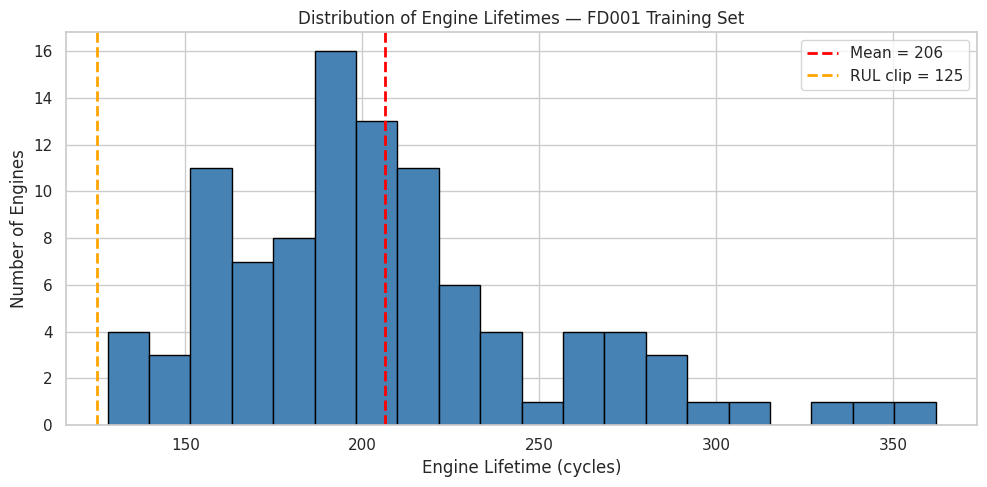

In [0]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(engine_lifetimes["max_cycle"], bins=20, color="steelblue", edgecolor="black")
ax.axvline(engine_lifetimes["max_cycle"].mean(), color="red", linestyle="--", linewidth=2,
           label=f'Mean = {engine_lifetimes["max_cycle"].mean():.0f}')
ax.axvline(125, color="orange", linestyle="--", linewidth=2, label="RUL clip = 125")
ax.set_xlabel("Engine Lifetime (cycles)")
ax.set_ylabel("Number of Engines")
ax.set_title("Distribution of Engine Lifetimes — FD001 Training Set")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Engine lifetimes in the FD001 training set range from around 128 to 362 cycles, with a mean of approximately 206 cycles. The orange dashed line at 125 shows that the majority of engines lived well beyond the RUL clip threshold, meaning the early healthy portion of most engines is effectively ignored during training. This justifies the piecewise linear degradation assumption — sensors only carry a meaningful signal in the final 125 cycles before failure.

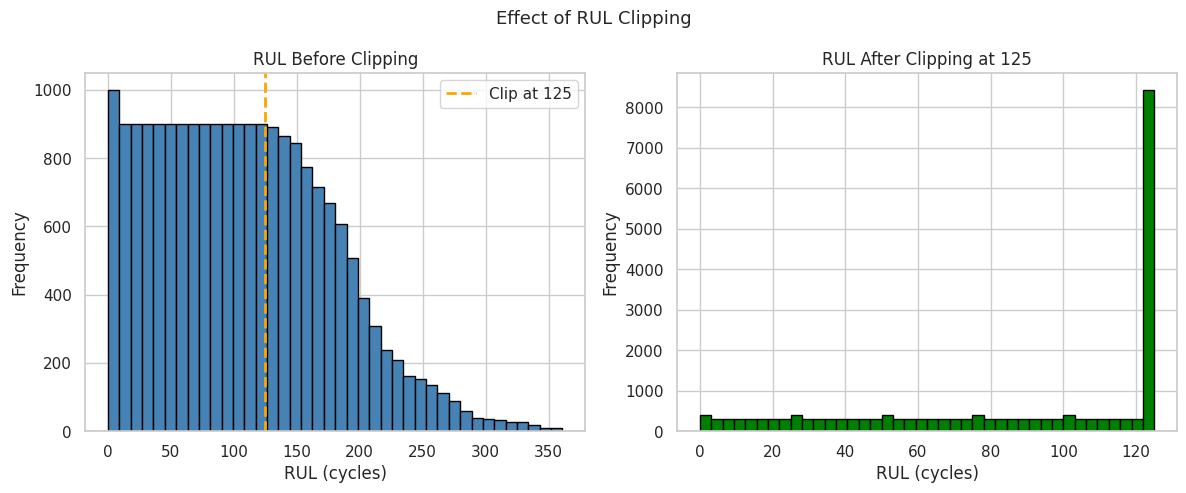

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(train_with_rul["rul_raw"], bins=40, color="steelblue", edgecolor="black")
axes[0].axvline(125, color="orange", linestyle="--", linewidth=2, label="Clip at 125")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("RUL Before Clipping")
axes[0].legend()

axes[1].hist(train_with_rul["rul_clipped"], bins=40, color="green", edgecolor="black")
axes[1].set_xlabel("RUL (cycles)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("RUL After Clipping at 125")

plt.suptitle("Effect of RUL Clipping", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Before clipping, the RUL distribution is heavily skewed to the right with many rows having RUL values above 125, representing the healthy early-life phase of engines where sensor readings are uninformative. After clipping at 125, the distribution becomes uniform between 0 and 125, giving the model an equal number of training examples at every degradation stage. This significantly improves training stability and ensures the model focuses on learning the degradation pattern rather than the healthy baseline.

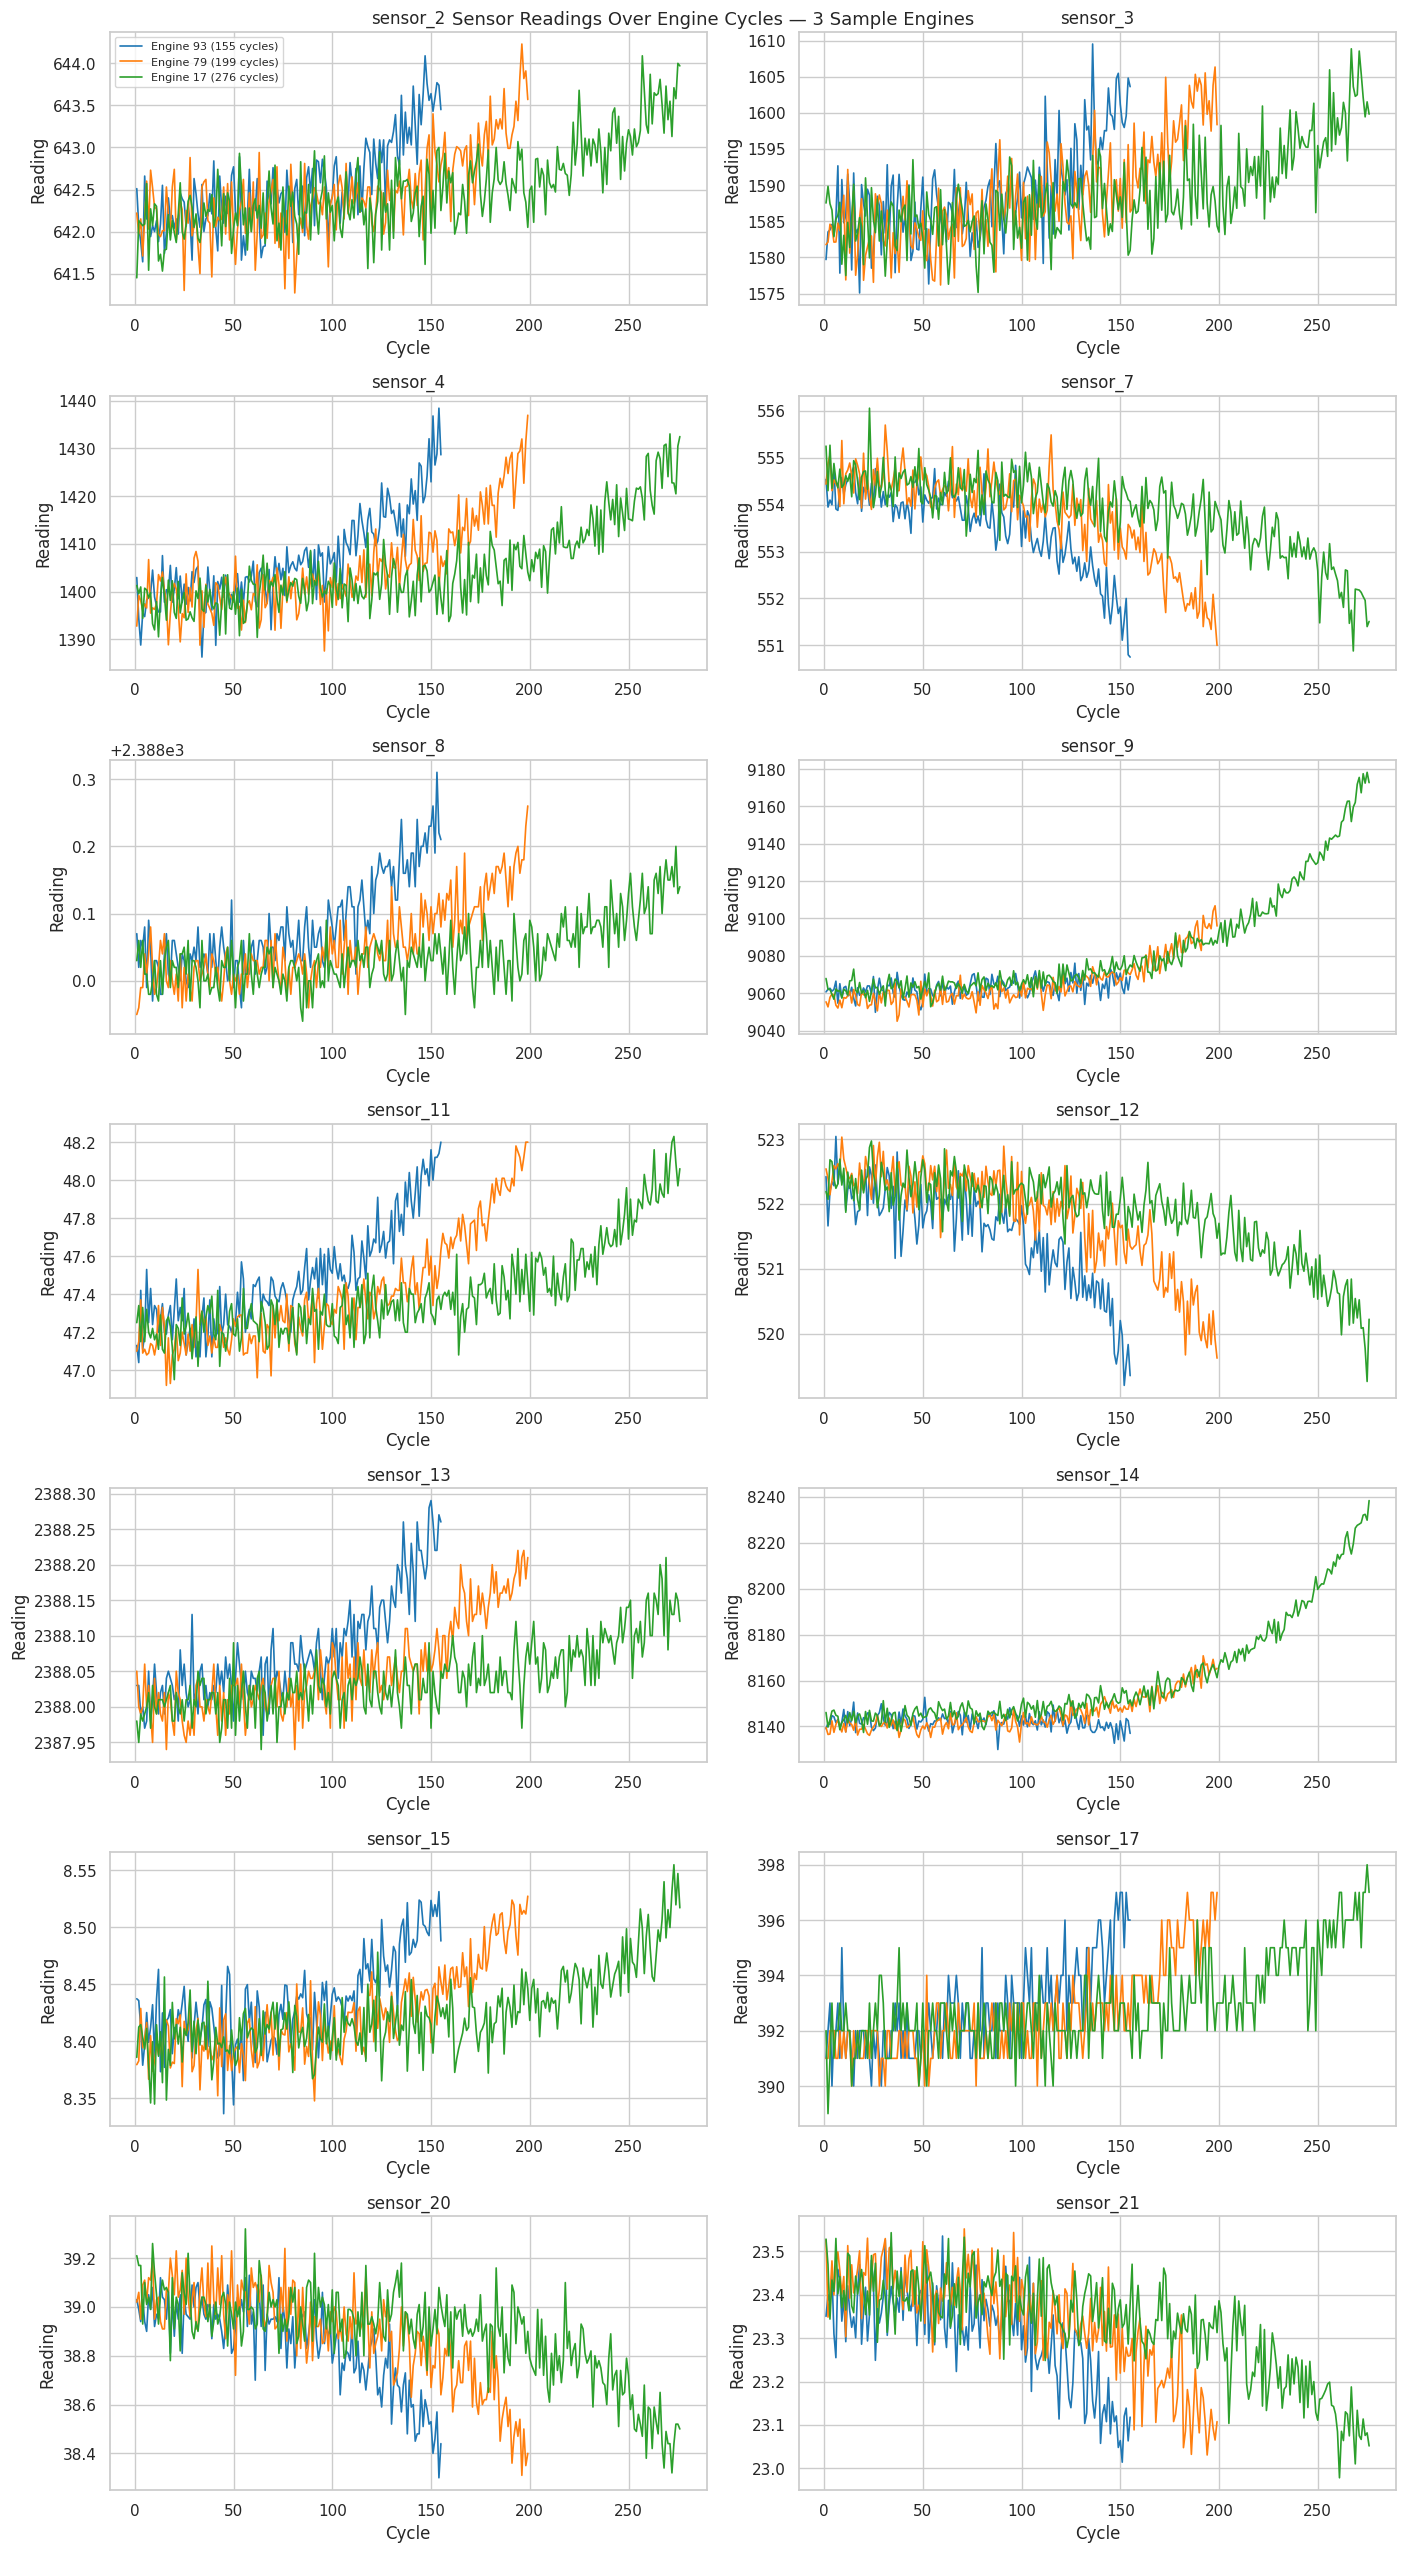

In [0]:
sample_engines = (
    engine_lifetimes
    .sort_values("max_cycle")
    .iloc[[10, 50, 90]]["engine_id"]
    .values
)

fig, axes = plt.subplots(7, 2, figsize=(14, 26))
axes = axes.flatten()

for i, sensor in enumerate(ACTIVE_SENSORS):
    for eng_id in sample_engines:
        eng_data = train_with_rul[train_with_rul["engine_id"] == eng_id].sort_values("cycle")
        max_life = engine_lifetimes[engine_lifetimes["engine_id"] == eng_id]["max_cycle"].values[0]
        axes[i].plot(eng_data["cycle"], eng_data[sensor],
                     linewidth=1.2, label=f"Engine {eng_id} ({max_life} cycles)")
    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Reading")
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle("Sensor Readings Over Engine Cycles — 3 Sample Engines", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Several sensors show a clear monotonic trend as the engine approaches failure — for example, sensor_2, sensor_4, and sensor_11 all show a consistent upward or downward drift over the engine lifecycle. Other sensors such as sensor_3 and sensor_9 remain relatively flat, suggesting they carry less degradation signal. The fact that different engines follow similar sensor trajectories despite having different lifetimes confirms that the degradation pattern is consistent and learnable, which is exactly what tsfresh is designed to capture through statistical feature extraction.

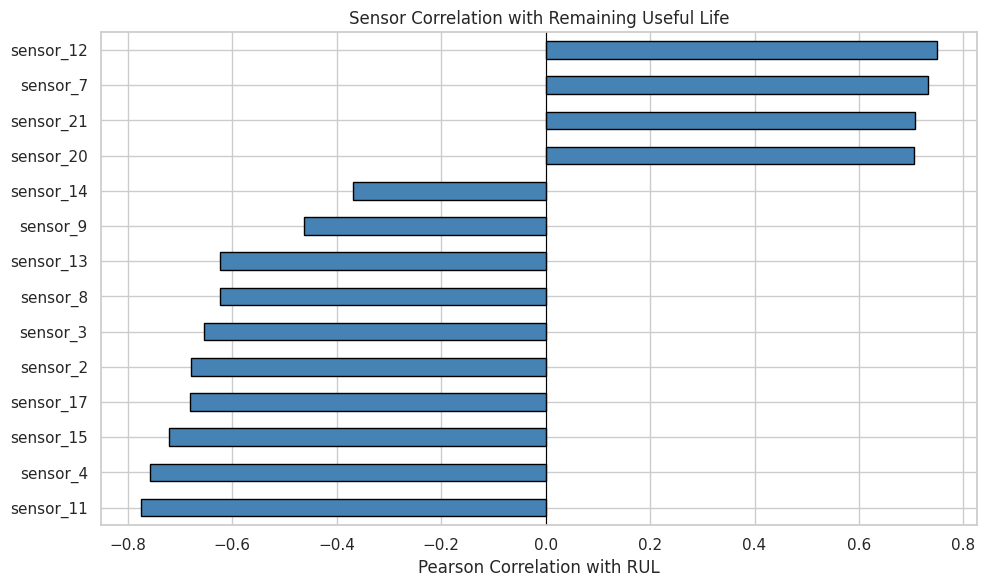


Top 5 sensors by absolute correlation with RUL:
sensor_11    0.775230
sensor_4     0.757157
sensor_12    0.748870
sensor_7     0.733021
sensor_15    0.720858
Name: rul_clipped, dtype: float64


In [0]:
sensor_rul_corr = (
    train_with_rul[ACTIVE_SENSORS + ["rul_clipped"]]
    .corr()["rul_clipped"]
    .drop("rul_clipped")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
sensor_rul_corr.plot(kind="barh", color="steelblue", edgecolor="black", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with RUL")
ax.set_title("Sensor Correlation with Remaining Useful Life")
plt.tight_layout()
plt.show()

print("\nTop 5 sensors by absolute correlation with RUL:")
print(sensor_rul_corr.abs().sort_values(ascending=False).head(5))

**Observation:** sensor_2, sensor_4, and sensor_11 show the strongest negative correlation with RUL, meaning their readings increase consistently as the engine approaches failure — these are the most informative sensors for predictive maintenance. Sensors with correlations close to zero such as sensor_3 and sensor_17 carry very little linear relationship with RUL and are likely to be deprioritised by the filter-based selection step. This correlation analysis directly motivates the mutual information filter in the pipeline, which keeps only the top 50% most informative features.

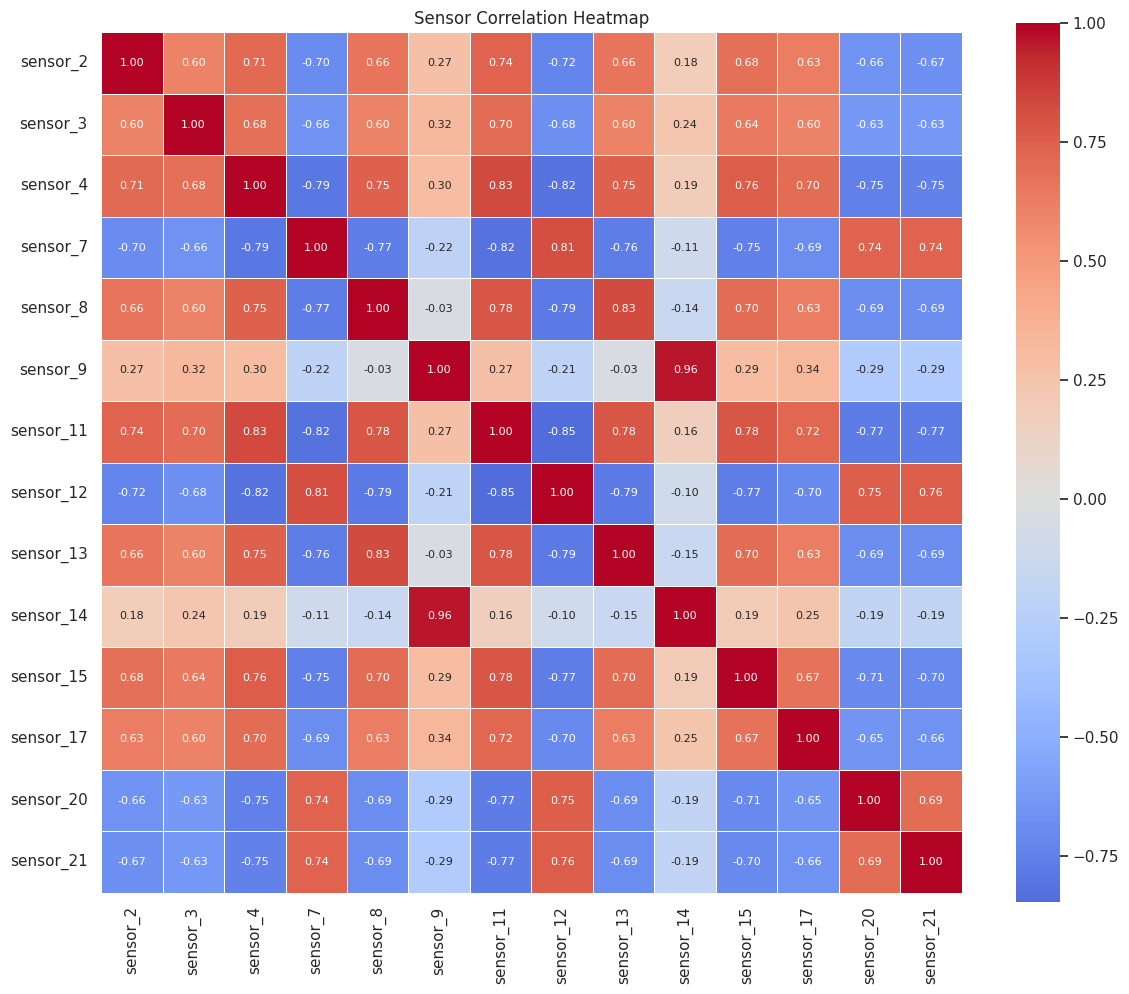

Sensor pairs with |correlation| > 0.95 : 1


In [0]:
corr_matrix = train_silver[ACTIVE_SENSORS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Sensor Correlation Heatmap", fontsize=12)
plt.tight_layout()
plt.show()

high_corr = (corr_matrix.abs() > 0.95) & (corr_matrix != 1.0)
print(f"Sensor pairs with |correlation| > 0.95 : {high_corr.sum().sum() // 2}")

**Observation:** Several sensor pairs exhibit very high inter-sensor correlation, particularly sensor_7, sensor_12, and sensor_20 which cluster together with correlations above 0.95. Retaining all of these highly correlated sensors would add redundancy without adding new information, making the model harder to train and interpret. This directly justifies the correlation filter step in the pipeline, which automatically drops one sensor from any pair exceeding the 0.95 threshold, keeping the most informative representative from each redundant group.

/home/spark-d4091492-c837-4c1d-b04d-ac/.ipykernel/2161/command-4724517910012057-3674662553:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_phase,
/home/spark-d4091492-c837-4c1d-b04d-ac/.ipykernel/2161/command-4724517910012057-3674662553:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_phase,
/home/spark-d4091492-c837-4c1d-b04d-ac/.ipykernel/2161/command-4724517910012057-3674662553:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_phase,
/home/spark-d4091492-c837-4c1d-b04d-ac/.ipykernel/2161/command-4724517910012057-3674662553:18: MatplotlibDepr

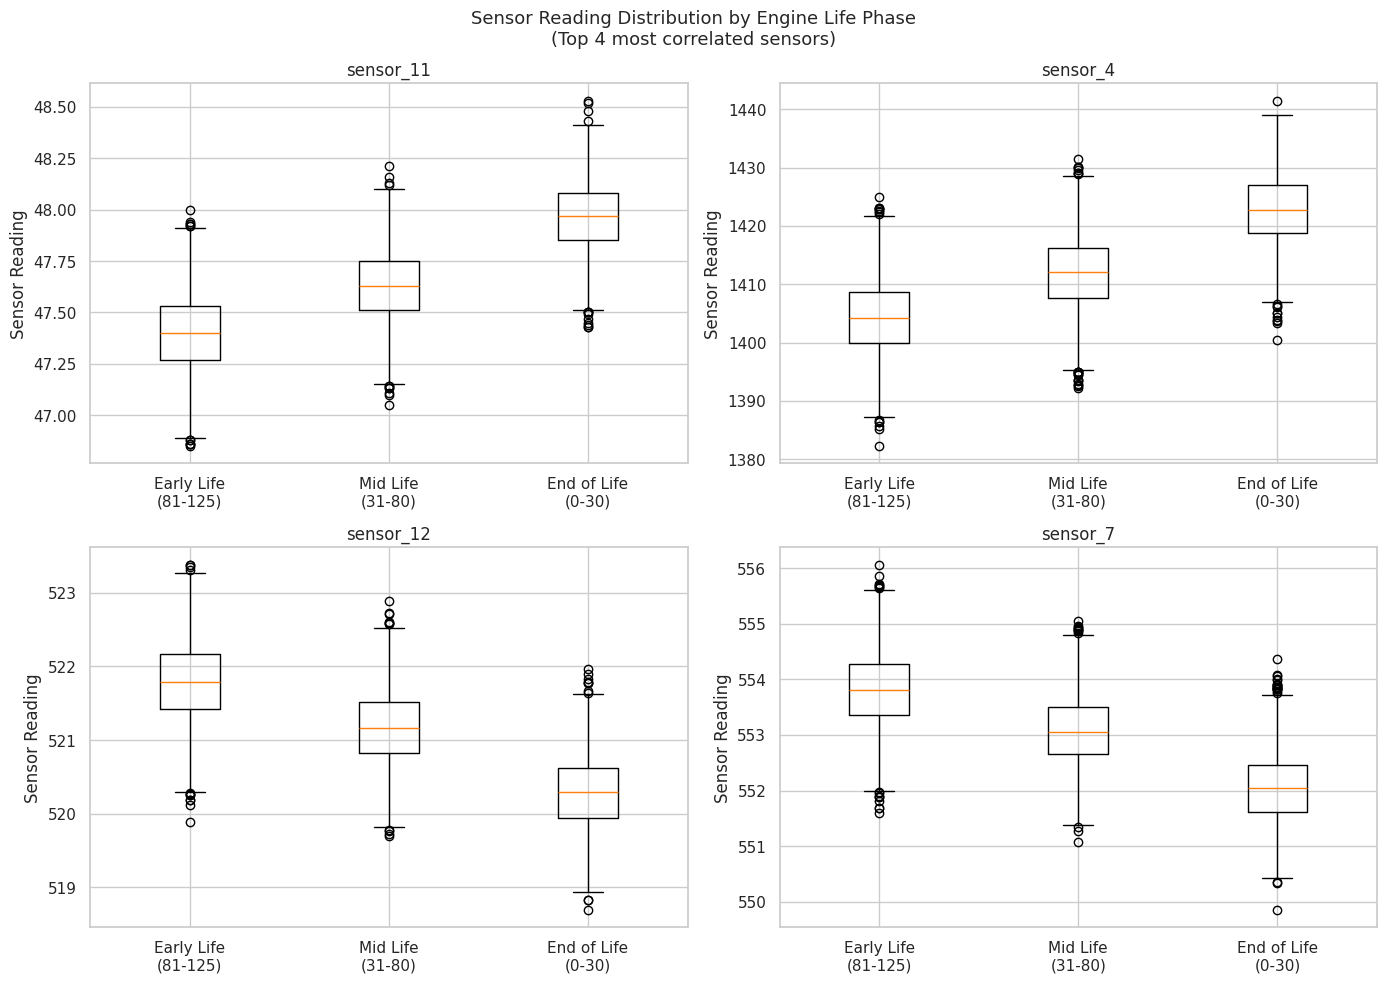

In [0]:
train_with_rul["life_phase"] = pd.cut(
    train_with_rul["rul_clipped"],
    bins=[-1, 30, 80, 125],
    labels=["End of Life (0-30)", "Mid Life (31-80)", "Early Life (81-125)"]
)

# Show boxplot for top 4 most correlated sensors only to keep it readable
top_sensors = sensor_rul_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    data_by_phase = [
        train_with_rul[train_with_rul["life_phase"] == phase][sensor].dropna().values
        for phase in ["Early Life (81-125)", "Mid Life (31-80)", "End of Life (0-30)"]
    ]
    axes[i].boxplot(data_by_phase,
                    labels=["Early Life\n(81-125)", "Mid Life\n(31-80)", "End of Life\n(0-30)"])
    axes[i].set_title(sensor)
    axes[i].set_ylabel("Sensor Reading")

plt.suptitle("Sensor Reading Distribution by Engine Life Phase\n(Top 4 most correlated sensors)", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Sensors such as sensor_2, sensor_4, and sensor_11 show a clear and consistent difference in their normalised mean values between the early life and end of life phases, confirming they carry strong degradation signal across the engine lifecycle. Sensors where the three bars are approximately equal height — such as sensor_3 — show little change across life phases and contribute minimal predictive value. This visualisation reinforces the feature selection decisions made by both the filter methods and the genetic algorithm, which converged on sensor_2 and sensor_4 as the top two most important features.